In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
import numpy as np
import sympy

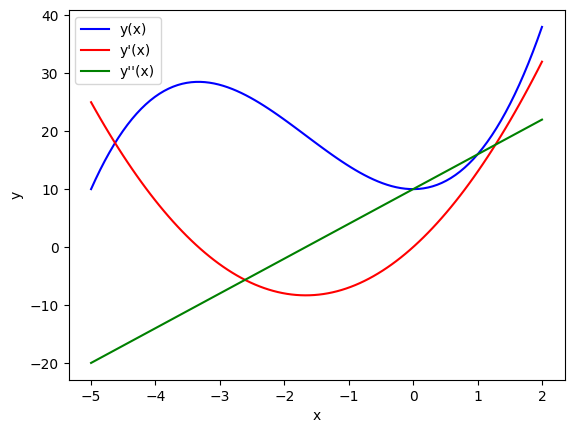

In [2]:
x = np.linspace(-5, 2, 100)
y1 = x**3 + 5*x**2 + 10
y2 = 3*x**2 + 10*x
y3 = 6*x + 10

fig, ax = plt.subplots()
ax.plot(x, y1, color="blue", label="y(x)")
ax.plot(x, y2, color="red", label="y'(x)")
ax.plot(x, y3, color="green", label="y''(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

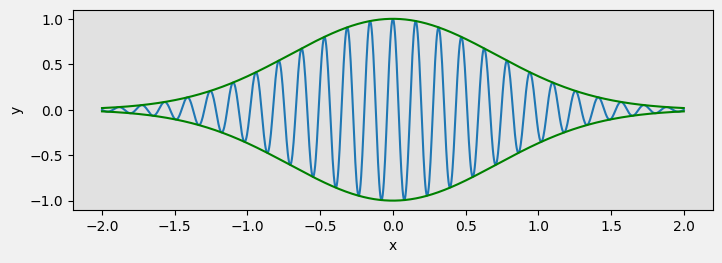

In [4]:
fig = plt.figure(figsize=(8, 2.5), facecolor="#f1f1f1")
# axes coordinates as fractions of the canvas width and height
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height), facecolor="#e1e1e1")
x = np.linspace(-2, 2, 1000)
y1 = np.cos(40 * x)
y2 = np.exp(-x**2)
ax.plot(x, y1 * y2)
ax.plot(x, y2, 'g')
ax.plot(x, -y2, 'g')
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.savefig("graph.png", dpi=100, facecolor="#f1f1f1")

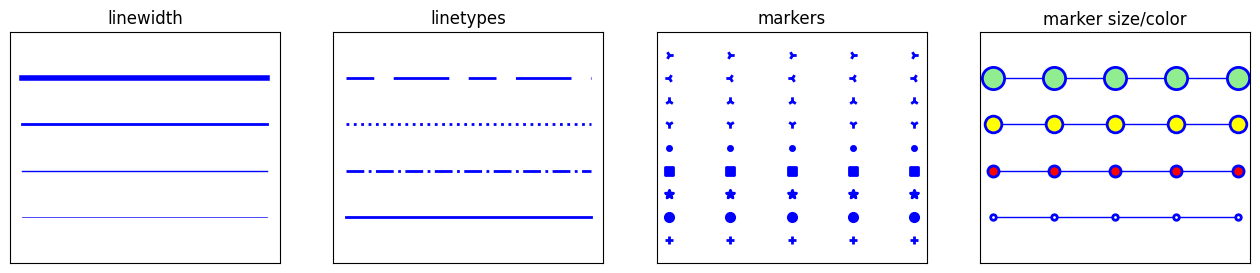

In [12]:
x = np.linspace(-5, 5, 5)
y = np.ones_like(x)
def axes_settings(fig, ax, title, ymax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(0, ymax+1)
    ax.set_title(title)
fig, axes = plt.subplots(1, 4, figsize=(16,3))
# Line width
linewidths = [0.5, 1.0, 2.0, 4.0]
for n, linewidth in enumerate(linewidths):
    axes[0].plot(x, y + n, color="blue", linewidth=linewidth)
axes_settings(fig, axes[0], "linewidth", len(linewidths))
# Line style
linestyles = ['-', '-.', ':']
for n, linestyle in enumerate(linestyles):
    axes[1].plot(x, y + n, color="blue", lw=2, linestyle=linestyle)
# custom dash style
line, = axes[1].plot(x, y + 3, color="blue", lw=2)
length1, gap1, length2, gap2 = 10, 7, 20, 7
line.set_dashes([length1, gap1, length2, gap2])
axes_settings(fig, axes[1], "linetypes", len(linestyles) + 1)
# marker types
markers = ['+', 'o', '*', 's', '.', '1', '2', '3', '4']
for n, marker in enumerate(markers):
# lw = shorthand for linewidth, ls = shorthand for linestyle
    axes[2].scatter(x, y + n, color="blue", lw=2, ls='-', marker=marker)
axes_settings(fig, axes[2], "markers", len(markers))
# marker size and color
markersizecolors = [(4, "white"), (8, "red"), (12, "yellow"), (16, "lightgreen")]
for n, (markersize, markerfacecolor) in enumerate(markersizecolors):
    axes[3].plot(x, y + n, color="blue", lw=1, ls='-',
        marker='o', markersize=markersize,
        markerfacecolor=markerfacecolor, markeredgewidth=2)
axes_settings(fig, axes[3], "marker size/color", len(markersizecolors))

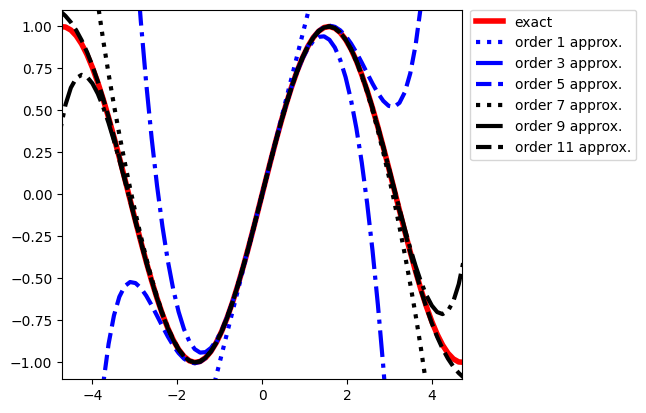

In [10]:
sym_x = sympy.Symbol("x")
x = np.linspace(-2 * np.pi, 2 * np.pi, 100)
def sin_expansion(x, n):
    """
    Evaluate the nth order Talyor series expansion
    of sin(x) for the numerical values in the array x.
    """
    return sympy.lambdify(sym_x, sympy.sin(sym_x).series(n=n+1).removeO(),'numpy')(x)

fig, ax = plt.subplots()
ax.plot(x, np.sin(x), linewidth=4, color="red", label='exact')
colors = ["blue", "black"]
linestyles = [':', '-.', '--']

for idx, n in enumerate(range(1, 12, 2)):
    ax.plot(x, sin_expansion(x, n), color=colors[idx // 3],
        linestyle=linestyles[idx % 3], linewidth=3,
        label="order %d approx." % n)

ax.set_ylim(-1.1, 1.1)
ax.set_xlim(-1.5*np.pi, 1.5*np.pi)
# place a legend outsize of the Axes
ax.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.0)
# make room for the legend to the right of the Axes
fig.subplots_adjust(right=.75)

Text(2, 0.1, 'Equation: $i\\hbar\\partial_t \\Psi = \\hat{H}\\Psi$')

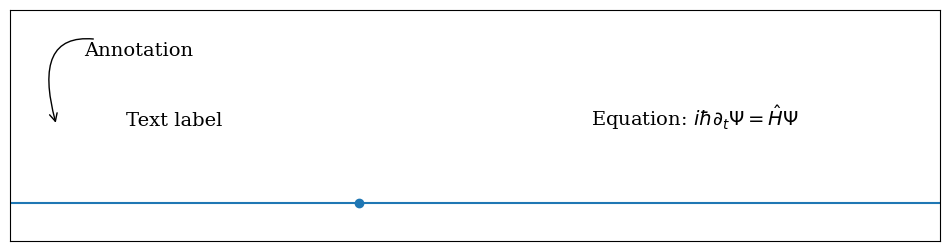

In [37]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.05, 0.25)
ax.axhline(0)

# text label
ax.text(0, 0.1, "Text label", fontsize=14, family="serif")

# annotation
ax.plot(1, 0, "o")
ax.annotate("Annotation",
    fontsize=14, family="serif",
    xy=(-0.3, 0.1), xycoords="data",
    xytext=(+20, +50), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3, rad=1"))

# equation
ax.text(2, 0.1, r"Equation: $i\hbar\partial_t \Psi = \hat{H}\Psi$",
    fontsize=14, family="serif")

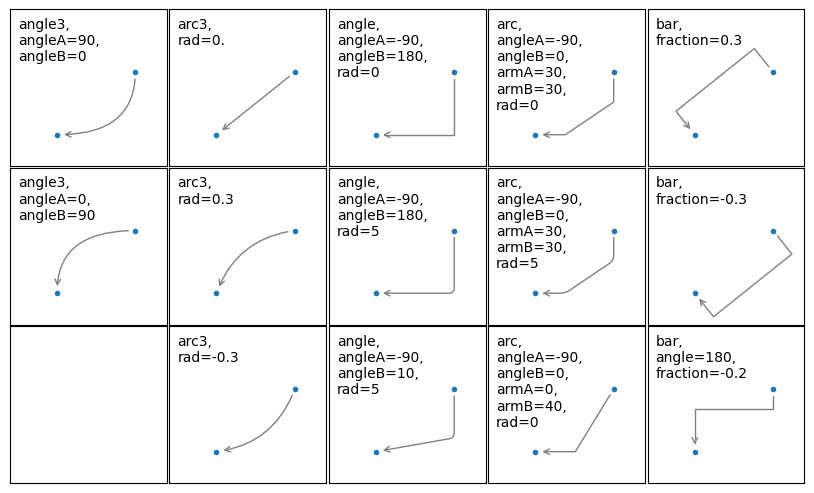

In [38]:
def demo_con_style(ax, connectionstyle):
    x1, y1 = 0.3, 0.2
    x2, y2 = 0.8, 0.6

    ax.plot([x1, x2], [y1, y2], ".")
    ax.annotate("",
                xy=(x1, y1), xycoords='data',
                xytext=(x2, y2), textcoords='data',
                arrowprops=dict(arrowstyle="->", color="0.5",
                                shrinkA=5, shrinkB=5,
                                patchA=None, patchB=None,
                                connectionstyle=connectionstyle,
                                ),
                )

    ax.text(.05, .95, connectionstyle.replace(",", ",\n"),
            transform=ax.transAxes, ha="left", va="top")


fig, axs = plt.subplots(3, 5, figsize=(8, 4.8))
demo_con_style(axs[0, 0], "angle3,angleA=90,angleB=0")
demo_con_style(axs[1, 0], "angle3,angleA=0,angleB=90")
demo_con_style(axs[0, 1], "arc3,rad=0.")
demo_con_style(axs[1, 1], "arc3,rad=0.3")
demo_con_style(axs[2, 1], "arc3,rad=-0.3")
demo_con_style(axs[0, 2], "angle,angleA=-90,angleB=180,rad=0")
demo_con_style(axs[1, 2], "angle,angleA=-90,angleB=180,rad=5")
demo_con_style(axs[2, 2], "angle,angleA=-90,angleB=10,rad=5")
demo_con_style(axs[0, 3], "arc,angleA=-90,angleB=0,armA=30,armB=30,rad=0")
demo_con_style(axs[1, 3], "arc,angleA=-90,angleB=0,armA=30,armB=30,rad=5")
demo_con_style(axs[2, 3], "arc,angleA=-90,angleB=0,armA=0,armB=40,rad=0")
demo_con_style(axs[0, 4], "bar,fraction=0.3")
demo_con_style(axs[1, 4], "bar,fraction=-0.3")
demo_con_style(axs[2, 4], "bar,angle=180,fraction=-0.2")

for ax in axs.flat:
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[], aspect=1)
fig.tight_layout(pad=0.2)

plt.show()

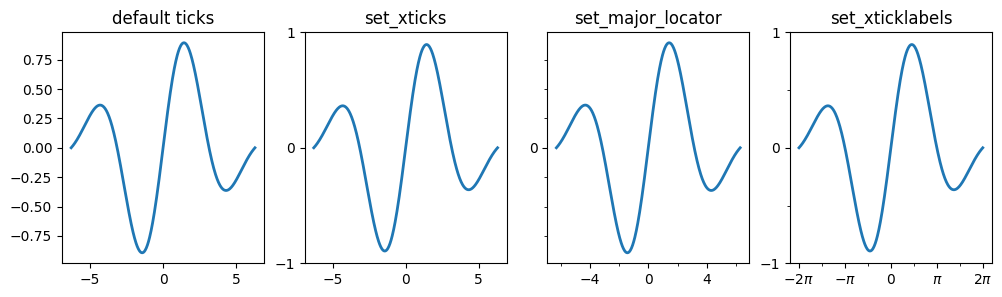

In [41]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 500)
y = np.sin(x) * np.exp(-x**2/20)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].plot(x, y, lw=2)
axes[0].set_title("default ticks")
axes[1].plot(x, y, lw=2)
axes[1].set_title("set_xticks")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_xticks([-5, 0, 5])
axes[2].plot(x, y, lw=2)
axes[2].set_title("set_major_locator")
axes[2].xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
axes[2].yaxis.set_major_locator(mpl.ticker.FixedLocator([-1, 0, 1]))
axes[2].xaxis.set_minor_locator(mpl.ticker.MaxNLocator(8))
axes[2].yaxis.set_minor_locator(mpl.ticker.MaxNLocator(8))
axes[3].plot(x, y, lw=2)
axes[3].set_title("set_xticklabels")
axes[3].set_yticks([-1, 0, 1])
axes[3].set_xticks([-2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi])
axes[3].set_xticklabels([r'$-2\pi$', r'$-\pi$', 0, r'$\pi$', r'$2\pi$'])
x_minor_ticker = mpl.ticker.FixedLocator([-3 * np.pi / 2, -np.pi/2, 0, np.pi/2, 3 * np.pi/2])
axes[3].xaxis.set_minor_locator(x_minor_ticker)
axes[3].yaxis.set_minor_locator(mpl.ticker.MaxNLocator(4))

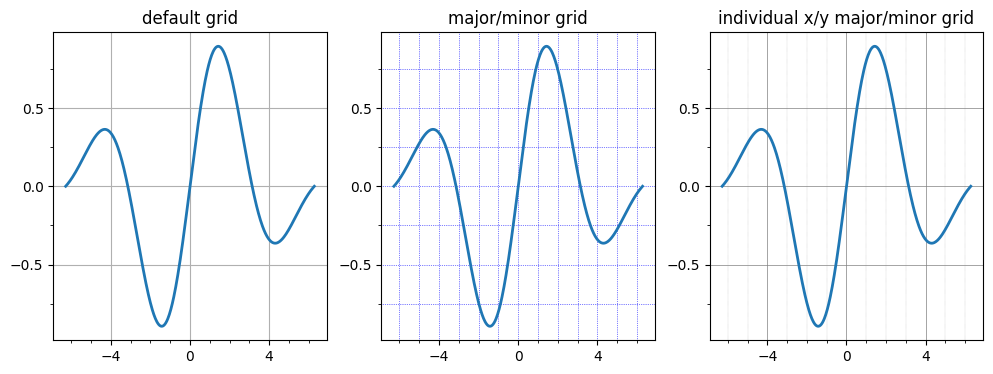

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
x_major_ticker = mpl.ticker.MultipleLocator(4)
x_minor_ticker = mpl.ticker.MultipleLocator(1)
y_major_ticker = mpl.ticker.MultipleLocator(0.5)
y_minor_ticker = mpl.ticker.MultipleLocator(0.25)
for ax in axes:
    ax.plot(x, y, lw=2)
    ax.xaxis.set_major_locator(x_major_ticker)
    ax.yaxis.set_major_locator(y_major_ticker)
    ax.xaxis.set_minor_locator(x_minor_ticker)
    ax.yaxis.set_minor_locator(y_minor_ticker)
    
axes[0].set_title("default grid")
axes[0].grid()
axes[1].set_title("major/minor grid")
axes[1].grid(color="blue", which="both", linestyle=':', linewidth=0.5)
axes[2].set_title("individual x/y major/minor grid")
axes[2].grid(color="grey", which="major", axis='x', linestyle='-', linewidth=0.5)
axes[2].grid(color="grey", which="minor", axis='x', linestyle=':', linewidth=0.25)
axes[2].grid(color="grey", which="major", axis='y', linestyle='-', linewidth=0.5)

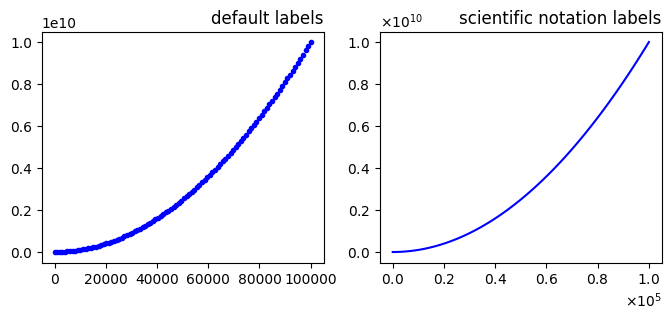

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
x = np.linspace(0, 1e5, 100)
y = x ** 2
axes[0].plot(x, y, 'b.')
axes[0].set_title("default labels", loc='right')
axes[1].plot(x, y, 'b')
axes[1].set_title("scientific notation labels", loc='right')
formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1))
axes[1].xaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)

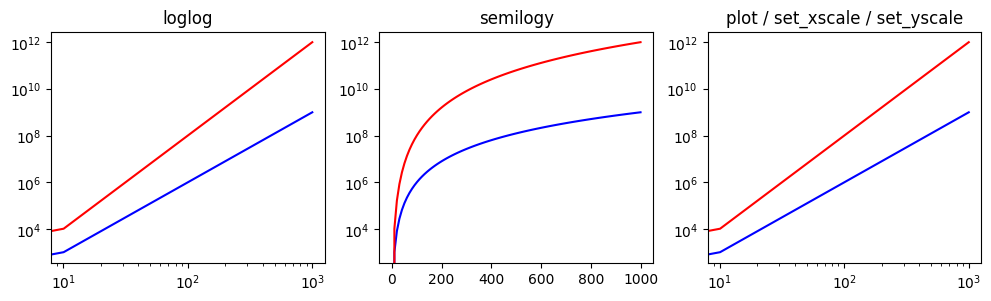

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
x = np.linspace(0, 1e3, 100)
y1, y2 = x**3, x**4
axes[0].set_title('loglog')
axes[0].loglog(x, y1, 'b', x, y2, 'r')
axes[1].set_title('semilogy')
axes[1].semilogy(x, y1, 'b', x, y2, 'r')
axes[2].set_title('plot / set_xscale / set_yscale')
axes[2].plot(x, y1, 'b', x, y2, 'r')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

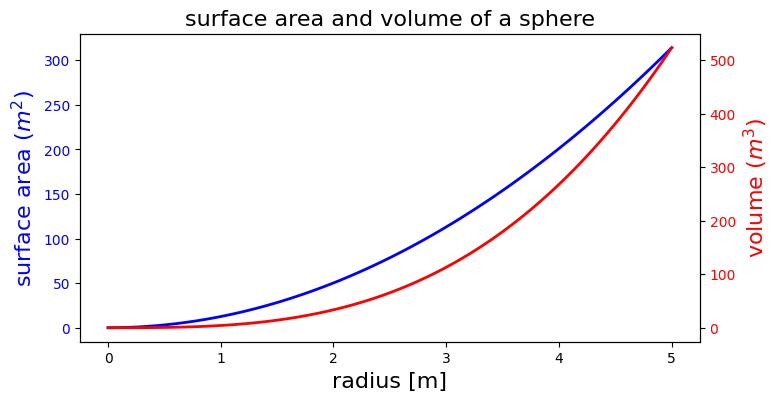

In [45]:
fig, ax1 = plt.subplots(figsize=(8, 4))
r = np.linspace(0, 5, 100)
a = 4 * np.pi * r ** 2 # area
v = (4 * np.pi / 3) * r ** 3 # volume
ax1.set_title("surface area and volume of a sphere", fontsize=16)
ax1.set_xlabel("radius [m]", fontsize=16)
ax1.plot(r, a, lw=2, color="blue")
ax1.set_ylabel(r"surface area ($m^2$)", fontsize=16, color="blue")
for label in ax1.get_yticklabels():
    label.set_color("blue")
ax2 = ax1.twinx()
ax2.plot(r, v, lw=2, color="red")
ax2.set_ylabel(r"volume ($m^3$)", fontsize=16, color="red")
for label in ax2.get_yticklabels():
    label.set_color("red")

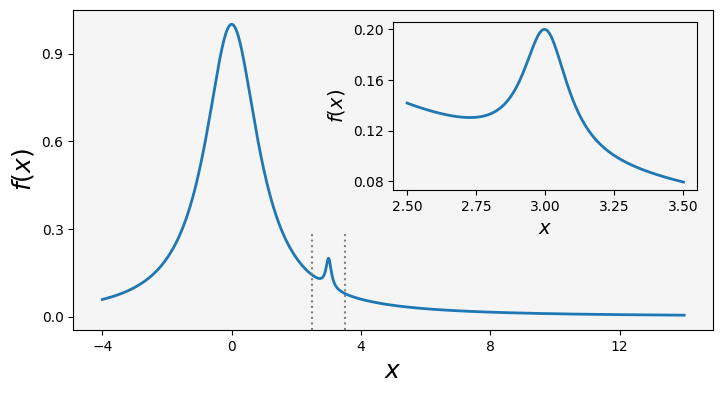

In [ ]:
fig = plt.figure(figsize=(8, 4))
def f(x):
    return 1/(1 + x**2) + 0.1/(1 + ((3 - x)/0.1)**2)

def plot_and_format_axes(ax, x, f, fontsize):
    ax.plot(x, f(x), linewidth=2)
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.set_xlabel(r"$x$", fontsize=fontsize)
    ax.set_ylabel(r"$f(x)$", fontsize=fontsize)
# main graph
ax = fig.add_axes([0.1, 0.15, 0.8, 0.8], facecolor="#f5f5f5")
x = np.linspace(-4, 14, 1000)
plot_and_format_axes(ax, x, f, 18)
# inset
x0, x1 = 2.5, 3.5
ax.axvline(x0, ymax=0.3, color="grey", linestyle=":")
ax.axvline(x1, ymax=0.3, color="grey", linestyle=":")
ax = fig.add_axes([0.5, 0.5, 0.38, 0.42], facecolor='none') #modificar posicion y estiramiento del inset
x = np.linspace(x0, x1, 1000)
plot_and_format_axes(ax, x, f, 14)


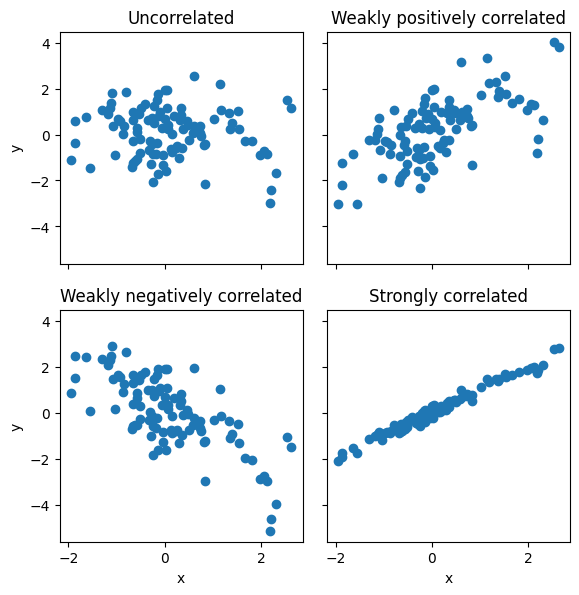

In [ ]:
fig, axes = plt.subplots( 2, 2, figsize=(6, 6), sharex=True, sharey=True, squeeze=False)

x1 = np.random.randn(100)
x2 = np.random.randn(100)

axes[0, 0].set_title("Uncorrelated")
axes[0, 0].scatter(x1, x2)

axes[0, 1].set_title("Weakly positively correlated")
axes[0, 1].scatter(x1, x1 + x2)

axes[1, 0].set_title("Weakly negatively correlated")
axes[1, 0].scatter(x1, -x1 + x2)

axes[1, 1].set_title("Strongly correlated")
axes[1, 1].scatter(x1, x1 + 0.15 * x2)

axes[1, 1].set_xlabel("x")
axes[1, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[1, 0].set_ylabel("y")
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95, wspace=0.1, hspace=0.2)

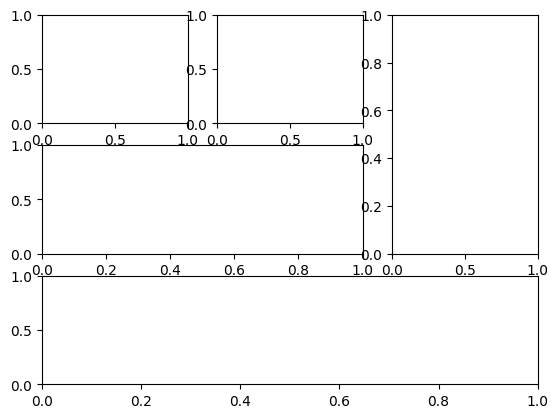

In [ ]:
ax0 = plt.subplot2grid((3, 3), (0, 0))
ax1 = plt.subplot2grid((3, 3), (0, 1))
ax2 = plt.subplot2grid((3, 3), (1, 0),colspan=2)
ax3 = plt.subplot2grid((3, 3), (2, 0),colspan=3)
ax4 = plt.subplot2grid((3, 3), (0, 2),rowspan=2)

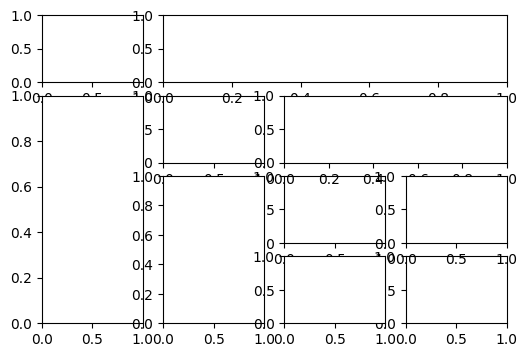

In [63]:
fig = plt.figure(figsize=(6, 4))
gs = mpl.gridspec.GridSpec(4, 4)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 1])
ax2 = fig.add_subplot(gs[2, 2])
ax3 = fig.add_subplot(gs[3, 3])
ax4 = fig.add_subplot(gs[0, 1:])
ax5 = fig.add_subplot(gs[1:, 0])
ax6 = fig.add_subplot(gs[1, 2:])
ax7 = fig.add_subplot(gs[2:, 1])
ax8 = fig.add_subplot(gs[2, 3])
ax9 = fig.add_subplot(gs[3, 2])

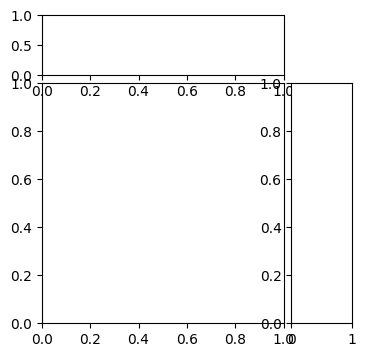

In [64]:
fig = plt.figure(figsize=(4, 4))
gs = mpl.gridspec.GridSpec(
2, 2,
width_ratios=[4, 1],
height_ratios=[1, 4],
wspace=0.05, hspace=0.05)
ax0 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 1])

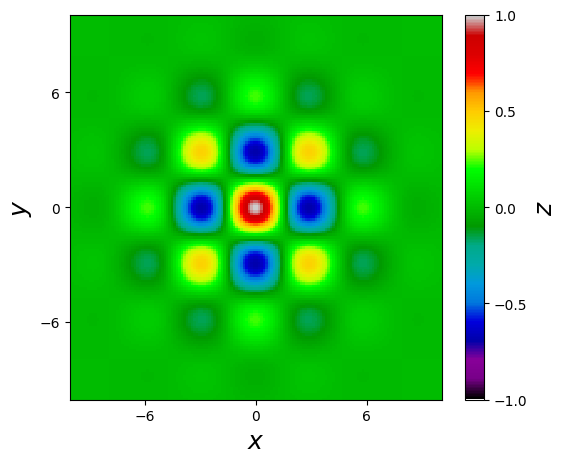

In [73]:
x = y = np.linspace(-10, 10, 150)
X, Y = np.meshgrid(x, y)
Z = np.cos(X) * np.cos(Y) * np.exp(-(X/5)**2-(Y/5)**2)
fig, ax = plt.subplots(figsize=(6, 5))
norm = mpl.colors.Normalize(-abs(Z).max(), abs(Z).max())
p = ax.pcolor(X, Y, Z, norm=norm, cmap='nipy_spectral')
ax.axis('tight')
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$y$", fontsize=18)
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
cb = fig.colorbar(p, ax=ax)
cb.set_label(r"$z$", fontsize=18)
cb.set_ticks([-1, -.5, 0, .5, 1])

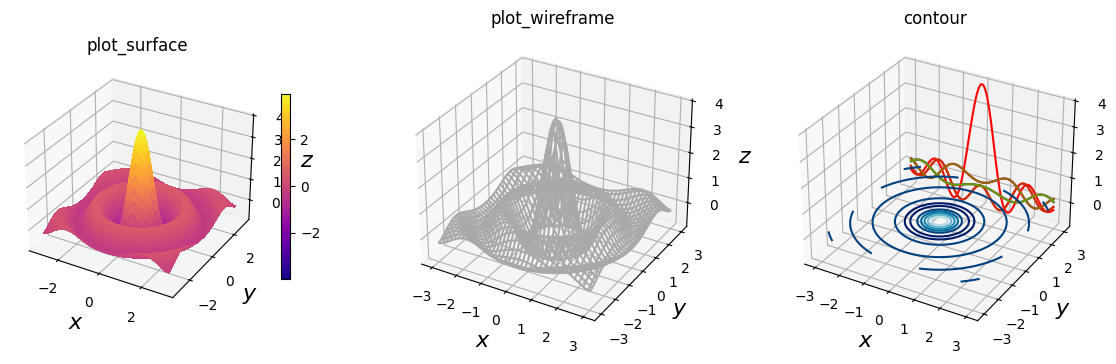

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), subplot_kw={'projection': '3d'})
def title_and_labels(ax, title):
    ax.set_title(title)
    ax.set_xlabel("$x$", fontsize=16)
    ax.set_ylabel("$y$", fontsize=16)
    ax.set_zlabel("$z$", fontsize=16)
x = y = np.linspace(-3, 3, 74)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(4 * R) / R
norm = mpl.colors.Normalize(-abs(Z).max(), abs(Z).max())
p = axes[0].plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0,antialiased=False, norm=norm, cmap='plasma')

cb = fig.colorbar(p, ax=axes[0], shrink=0.6)
title_and_labels(axes[0], "plot_surface")
axes[1].plot_wireframe(X, Y, Z, rstride=2, cstride=2, color="darkgrey")
title_and_labels(axes[1], "plot_wireframe")
axes[2].contour(X, Y, Z, zdir='z', offset=0, norm=norm, cmap='ocean')
axes[2].contour(X, Y, Z, zdir='y', offset=3, norm=norm, cmap='brg')
title_and_labels(axes[2], "contour")

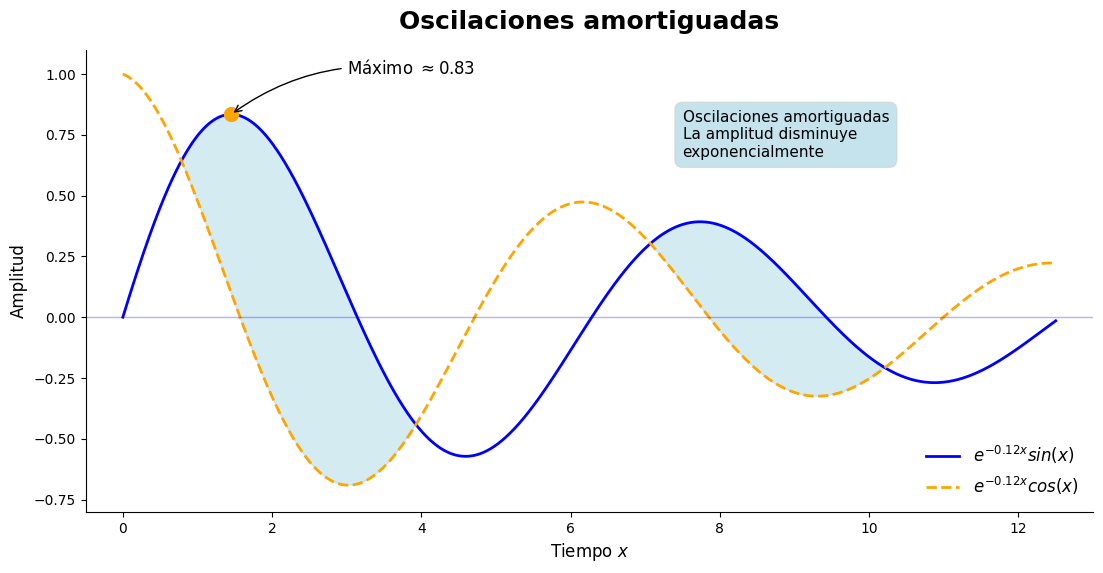

In [145]:
x = np.linspace(0, 12.5, 1000)
y1 = np.exp(-0.12 * x) * np.sin(x)  
y2 = np.exp(-0.12 * x) * np.cos(x)  

fig,ax = plt.subplots(figsize=(13, 6))
plt.plot(x, y1, color='blue', linewidth=2, label=r'$e^{-0.12x}sin(x)$')
plt.plot(x, y2, color='orange', linewidth=2, linestyle='--', label=r'$e^{-0.12x}cos(x)$')

plt.axhline(0, color='blue', linewidth=1, alpha=0.3)
plt.fill_between(x, y1, y2, where=(y1>y2), color='lightblue', alpha=0.5)

plt.plot(x[np.argmax(y1)], np.max(y1), marker='o', markersize=10, color='orange')

plt.annotate(r'Máximo $\approx 0.83$',
            xy=(x[np.argmax(y1)], np.max(y1)), 
            xytext=(3, 1), 
            fontsize=12,
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black'))

texto = "Oscilaciones amortiguadas\nLa amplitud disminuye\nexponencialmente"
plt.text(7.5, 0.75, texto, fontsize=11, 
                            bbox=dict(
                                    boxstyle='round,pad=0.5', 
                                    facecolor='lightblue', 
                                    edgecolor='lightgray',
                                    alpha=0.7), 
                            va='center')

plt.title("Oscilaciones amortiguadas", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Tiempo $x$", fontsize=12)
plt.ylabel("Amplitud", fontsize=12)

plt.xlim(-0.5, 13)
plt.ylim(-0.8, 1.1)
plt.xticks(np.arange(0, 13, 2))
plt.yticks(np.arange(-0.75, 1.25, 0.25))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='lower right', frameon=False, fontsize=12)
